
<table width="100%">
  <td style="font-size:30px;text-align:left;background-color:rgba(150, 123, 182, 0.7);font-style:italic;">
    Grover's algorithm.<br>
    <span style="font-size:25px;font-style:normal;">
      Borja Álvarez Reguera & Alicia de la Varga Cabero.
    </span>
  </td>
</table>

<p style="font-size:22px; font-weight:bold;">Grover's algorithm.</p>

**Grover's algorithm** is a quantum algorithm designed to search an unsorted database or find a marked element in a set of $N = 2^n$ items with quadratic speedup over classical search.  
Classically, to find a target item, one may need to check up to $N$ elements in the worst case.  
Quantum mechanically, Grover's algorithm can locate a **marked element** with high probability using approximately $\mathcal{O}(\sqrt{N})$ oracle queries.

The algorithm relies on two key components:
1. A **quantum oracle** $O_f$ that flips the phase of the target state(s):  
   $$
   O_f |x\rangle = 
   \begin{cases}
   -|x\rangle & \text{if } x \text{ is a target state} \\
   |x\rangle & \text{otherwise}
   \end{cases}
   $$
2. A **diffusion operator** (or amplitude amplification) that amplifies the probability amplitude of the marked state(s) while reducing the amplitudes of the non-target states.

In this task, we will:
- Implement a **several Grover oracles** that marks different target states.
- Construct a **Grover wrapper function** that runs the full algorithm for any given target(s) and number of q-bits $n$.
- Test the algorithm with different targets and analyze the resulting measurement histograms, highlighting the quantum speedup and amplitude amplification effects.

In [1]:
# Import packages & classes
    # Classical Python Packages
import numpy as np
import matplotlib.pyplot as plt
    # Qiskit tools :)
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

<p style="font-size:18px; font-weight:bold;">Oracles construction.</p>

In this section, we build several **oracles** $U_f$ for **Grover's algorithm**, which acts on computational basis states as  

$$
U_f |x\rangle = 
\begin{cases}
-|x\rangle & \text{if } x \text{ satisfies the search criterion} \\
|x\rangle & \text{otherwise}
\end{cases}
$$

This means that the **phase of the marked state(s)** is flipped, allowing Grover’s algorithm to amplify their probability amplitude through interference.

We will implement **two different oracles** for demonstration:

1. **Single target oracle**: marks a unique, user-defined number. This is useful to test the basic Grover search for a specific state.  
2. **Prime number oracle**: marks all numbers that are prime. In this case, there are multiple marked states, demonstrating amplitude amplification across several targets.

The oracles are constructed dynamically by:
1. Converting the target number(s) into their binary representation.  
2. Applying $X$ gates to map the marked basis state(s) temporarily to $|11\dots1\rangle$.  
3. Applying a multi-controlled $Z$ gate to flip the phase of the mapped state(s).  
4. Undoing the $X$ gates to return to the computational basis.

This approach allows us to generate **custom oracles programmatically**, enabling experimentation with different types of search problems using Grover's algorithm.

In [2]:
# --- 1. Single target oracle ---
def oracle_single_target(qc, target, n):
    """
    Marks a single target state |target> among n q-bits.
    
    Parameters:
        qc (QuantumCircuit): Quantum circuit to apply the oracle on.
        target (int): Integer representing the target state to mark.
        n (int): Number of q-bits in the input register.
    """
    target_bin = format(target, f'0{n}b')
    
    # Apply X to q-bits that are 0 in target
    for i, bit in enumerate(target_bin):
        if bit == '0': qc.x(i)
    
    # Apply multi-controlled X (phase kickback)
    qc.mcx(list(range(n)), n)
    
    # Undo X gates
    for i, bit in enumerate(target_bin):
        if bit == '0': qc.x(i)

# --- 2. Prime number oracle ---
def is_prime(k):
    """Check if an integer k >= 0 is prime."""
    if k < 2:
        return False
    for j in range(2, int(k**0.5) + 1):
        if k % j == 0:
            return False
    return True

def oracle_primes(qc, n):
    """
    Marks all states whose value is a prime number.
    
    Parameters:
        qc (QuantumCircuit): Quantum circuit to apply the oracle on.
        n (int): Number of q-bits in the input register.
    """
    for i in range(2**n):
        if is_prime(i): oracle_single_target(qc, i, n)

<p style="font-size:18px; font-weight:bold;">Algorithm outline & implementation.</p>

Grover's algorithm is designed to **find one or more marked states** in an unsorted database of size $N = 2^n$ using amplitude amplification. In our implementation, we will use $n$ input q-bits and one ancilla to mark specific states.

1. **Initialization**  
   Start with $n$ input q-bits in the state $|0\rangle^{\otimes n}$. Apply Hadamard gates to create a **uniform superposition** over all $2^n$ possible states:  
   $$
   \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n-1} |x\rangle
   $$

2. **Oracle application**  
   Apply the Grover **oracle** $U_f$, which flips the phase of the **marked states**:  
   $$
   U_f |x\rangle = 
   \begin{cases}
   -|x\rangle & \text{if $x$ is a marked state} \\
   |x\rangle & \text{otherwise}
   \end{cases}
   $$  
   In our experiments, we will implement **two types of oracles**:
   - **Single-target oracle**: marks a single number, e.g., $x=5$.
   - **Prime number oracle**: marks all states that are prime numbers.

3. **Diffusion (Amplitude amplification)**  
   Apply the **Grover diffusion operator**, which inverts amplitudes about the mean. This step **amplifies the probability** of measuring the marked states.

4. **Iteration**  
   Repeat the **oracle + diffusion** sequence approximately $\lfloor \pi/4 \cdot \sqrt{N/M} \rfloor$ times, where $M$ is the number of marked states. This maximizes the probability of measuring a marked state.

5. **Measurement**  
   Measure all input q-bits. The outcome will, with high probability, be one of the marked states.

---

In our implementation, we will:
- Construct the circuit dynamically for any number of q-bits $n$.
- Apply the oracle and diffusion steps iteratively.
- Simulate the circuit and plot **histograms** showing the measurement probabilities of each state.
- Verify that the algorithm successfully amplifies the amplitudes of the marked states for each oracle type.


In [3]:
def grover_run(oracle_func, target, n, num_solutions=1, shots=1024):
    """
    Runs Grover's algorithm for a given oracle on n q-bits.

    Parameters:
        oracle_func (function): Function that builds a Grover oracle on a QuantumCircuit.
                                Signature: oracle_func(qc, target, n) or oracle_func(qc, n)
        target (int or None): Target state (for single-target oracle) or None for prime number oracle.
        n (int): Number of input q-bits.
        num_solutions (int): Number of marked states (M) for Grover's iteration count.
        shots (int): Number of shots for simulation measurement.

    Returns:
        qc (QuantumCircuit): The final quantum circuit.
        counts (dict): Measurement outcomes from the input register.
    """

    # --- Step 1: Build quantum circuit ---
    qc = QuantumCircuit(n + 1, n)  # n input q-bits + 1 ancilla, n classical bits

    # --- Step 2: Apply Hadamard gates to input q-bits ---
    for i in range(n):
        qc.h(i)
    qc.barrier()

    # --- Step 3: Compute number of Grover iterations ---
    N = 2**n
    num_iterations = max(1, int(np.round((np.pi/4) * np.sqrt(N/num_solutions))))

    # --- Step 4: Grover iterations ---
    for _ in range(num_iterations):
        # Initialize ancilla in |-> for phase kickback
        qc.x(n)
        qc.h(n)

        # Apply oracle
        if oracle_func.__name__ == "oracle_single_target":
            oracle_func(qc, target, n)
        else:
            oracle_func(qc, n)

        qc.barrier()

        # Diffusion operator
        for i in range(n): qc.h(i)
        for i in range(n): qc.x(i)
        if n == 1:
            qc.z(0)
        else:
            qc.h(n-1)
            qc.mcx(list(range(n-1)), n-1)
            qc.h(n-1)
        for i in range(n): qc.x(i)
        for i in range(n): qc.h(i)
        qc.barrier()

    # --- Step 5: Measure input q-bits ---
    for i in range(n):
        qc.measure(i, i)

    # --- Step 6: Simulate measurement ---
    sim = AerSimulator()
    counts = sim.run(transpile(qc, sim), shots=shots).result().get_counts()
    counts = {k[::-1]: v for k, v in counts.items()}  # Convert to big-endian

    # --- Step 7: Display circuit and results ---
    display(qc.draw('mpl'))
    return qc, counts

<p style="font-size:18px; font-weight:bold;">Testing Grover's algorithm.</p>

Now that we have implemented **Grover's algorithm** and several custom oracles, it is time to verify that the algorithm behaves as expected.

We will test the following oracles:

1. **Single marked state** – an oracle that marks a single specific state (e.g., |5⟩ for 3 q-bits).  
   The algorithm should amplify the probability of measuring this state close to 1 after the appropriate number of Grover iterations.

2. **Prime number oracle** – marks all 4-bit numbers that are prime (2, 3, 5, 7, 11, 13).  
   Similarly, the histogram should indicate amplification of these marked prime states.

For each oracle, we will:

- Run Grover's algorithm with a number of iterations appropriate for the number of marked states.  
- Collect measurement results over multiple shots (e.g., 1024) to observe the probability distribution.  
- Verify that the most probable outcomes correspond to the **marked states** defined by the oracle.

This approach demonstrates how Grover's algorithm can be used for **search problems**, amplifying the amplitudes of desired states and allowing them to be found with high probability.



--- Testing Grover's algorithm: Single marked state |5>, n=3 ---


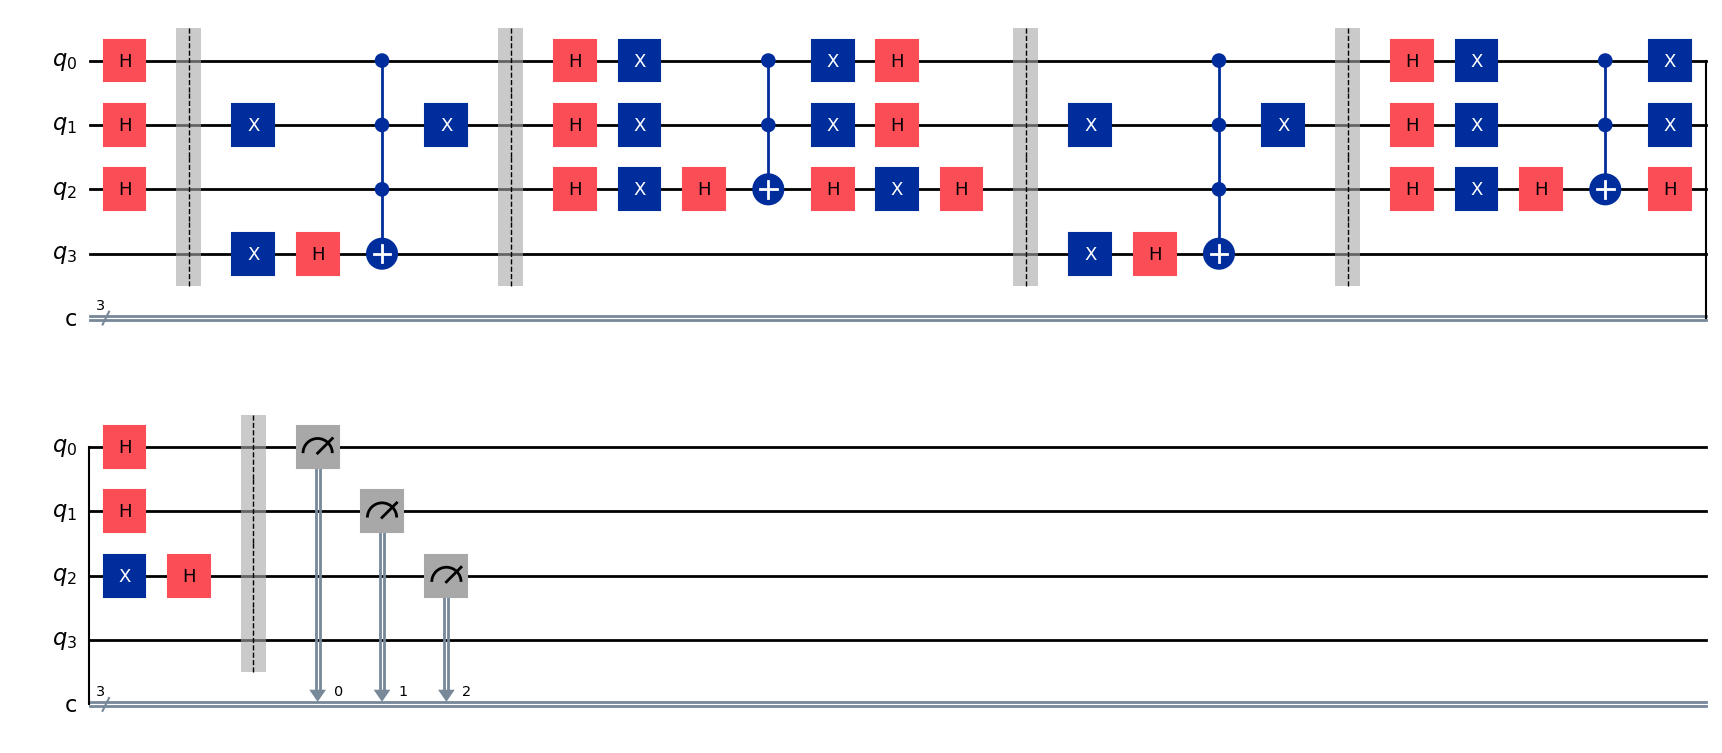

Measurement histogram (top states amplified):
000 (0): 147
001 (1): 142
010 (2): 141
011 (3): 146
100 (4): 119
101 (5): 1049
110 (6): 148
111 (7): 156

--- Testing Grover's algorithm: Single marked state |12>, n=4 ---


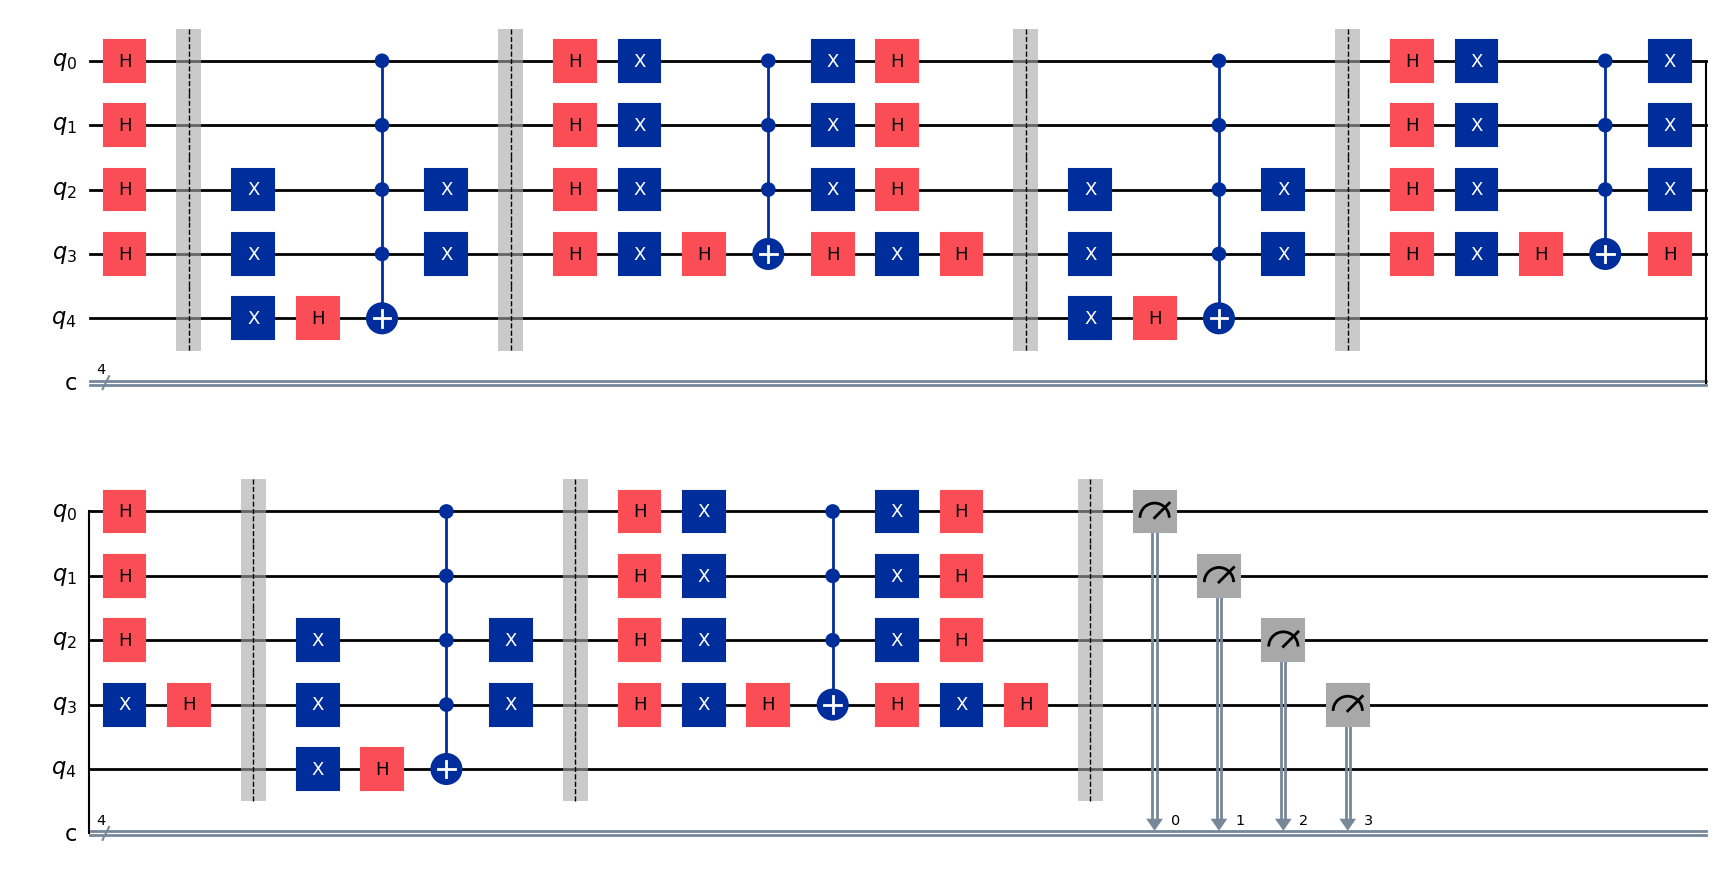

Measurement histogram (top states amplified):
0000 (0): 94
0001 (1): 118
0010 (2): 136
0011 (3): 115
0100 (4): 115
0101 (5): 124
0110 (6): 107
0111 (7): 127
1000 (8): 126
1001 (9): 130
1010 (10): 122
1011 (11): 137
1100 (12): 254
1101 (13): 105
1110 (14): 129
1111 (15): 109

--- Testing Grover's algorithm: 4-bit primes, n=4 ---


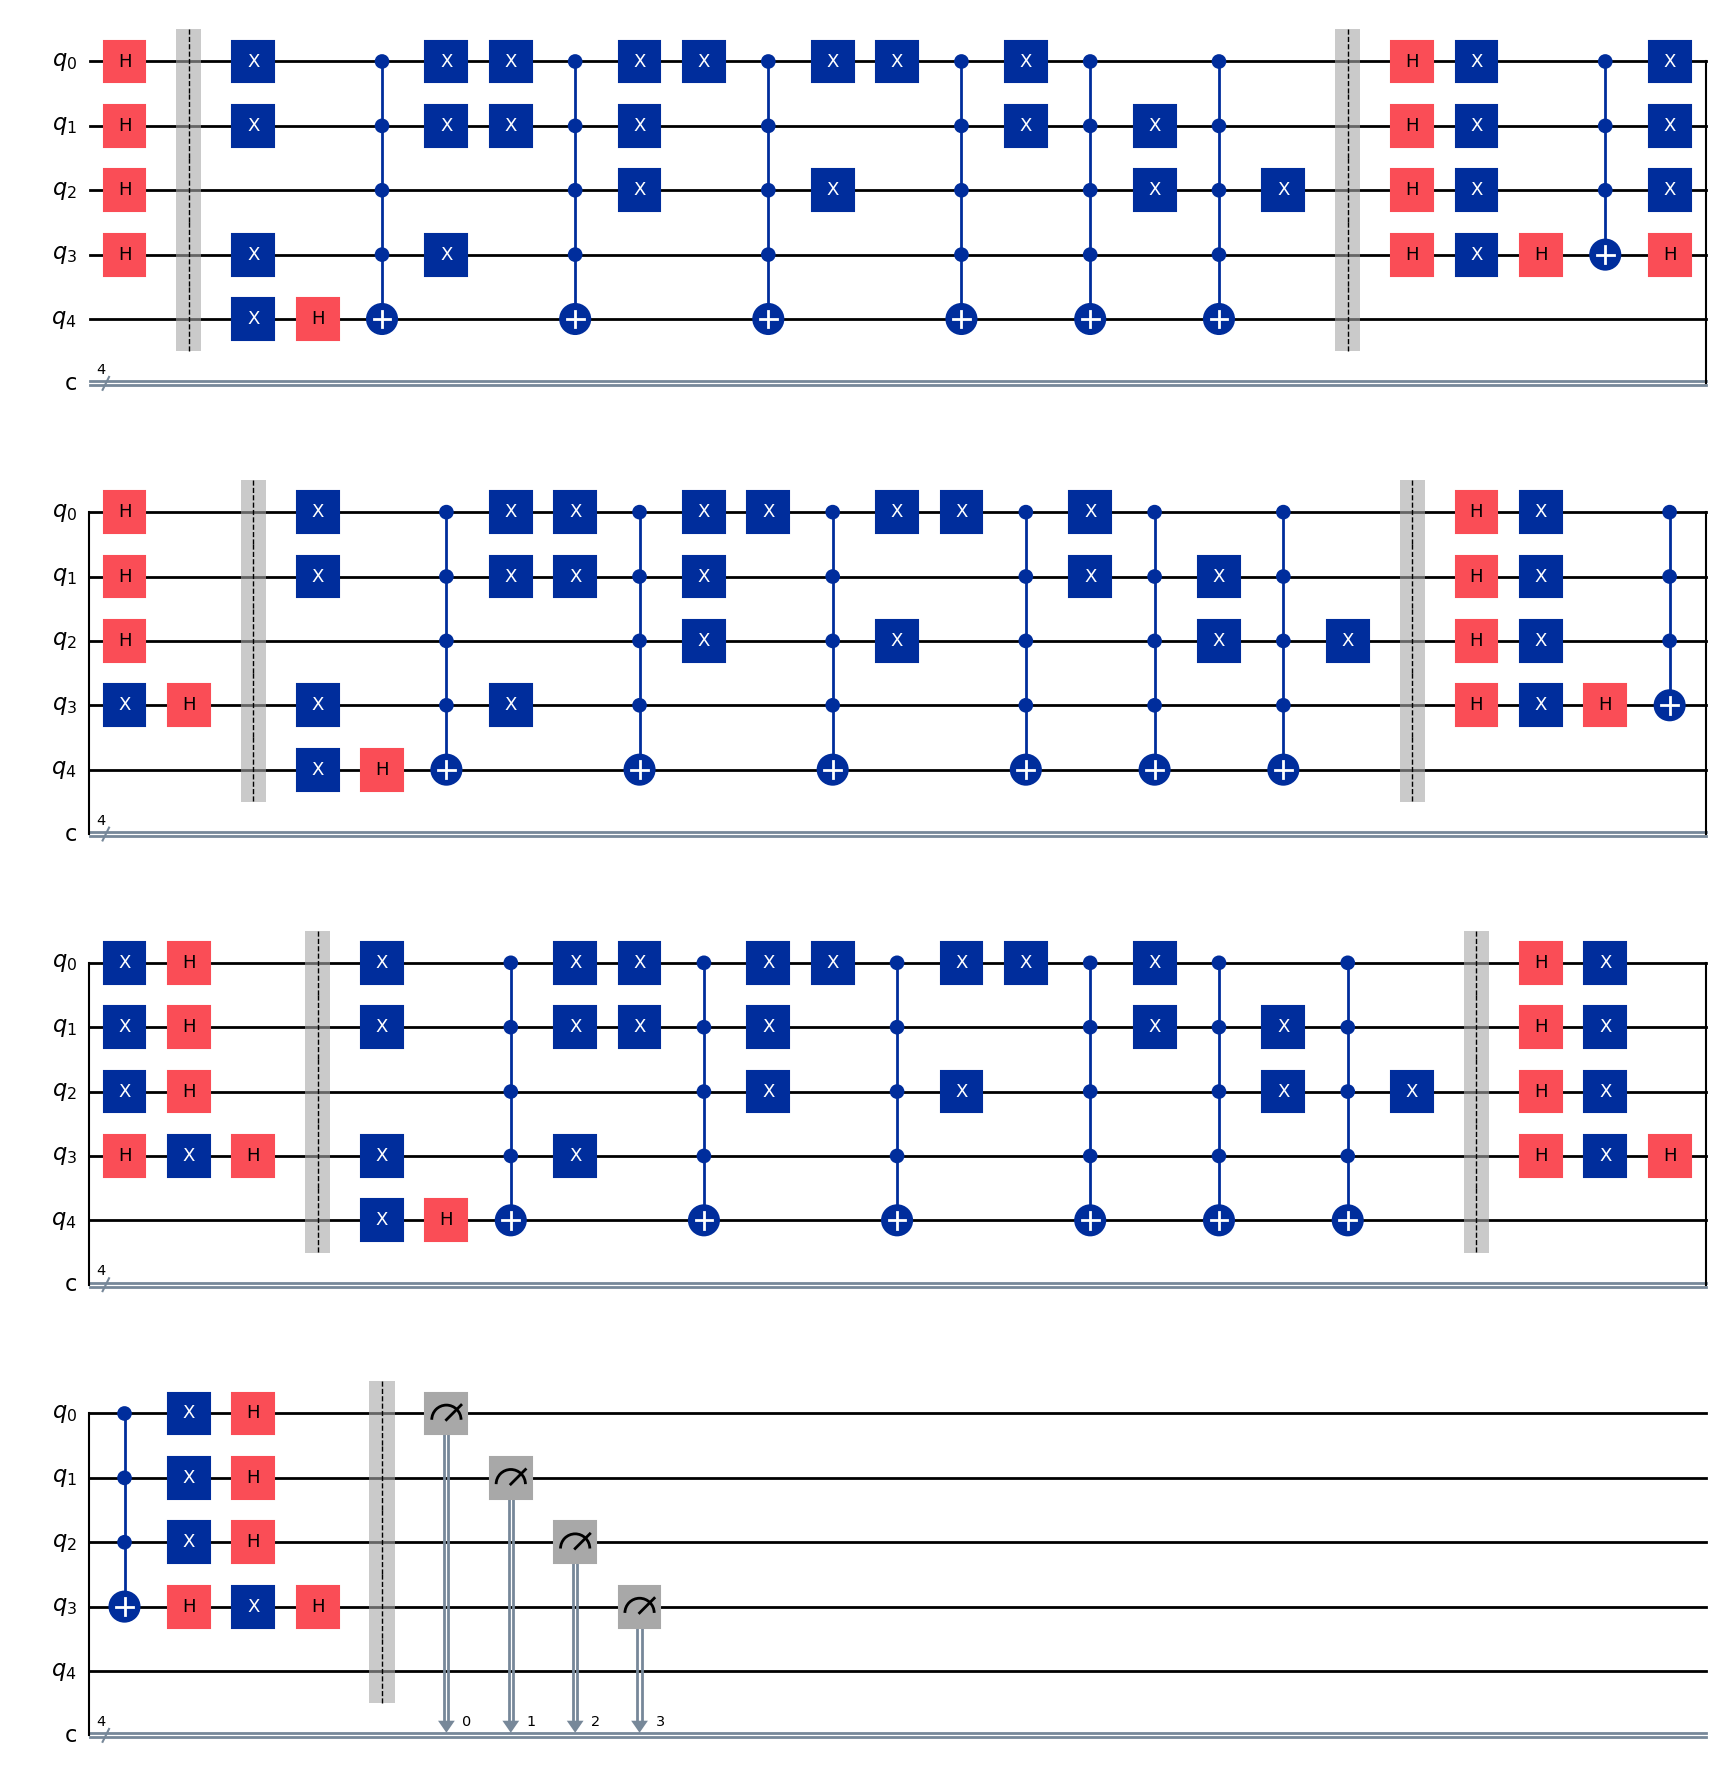

Measurement histogram (top states amplified):
0000 (0): 63
0001 (1): 76
0010 (2): 224
0011 (3): 206
0100 (4): 89
0101 (5): 202
0110 (6): 86
0111 (7): 240
1000 (8): 76
1001 (9): 80
1010 (10): 65
1011 (11): 208
1100 (12): 81
1101 (13): 221
1110 (14): 75
1111 (15): 56


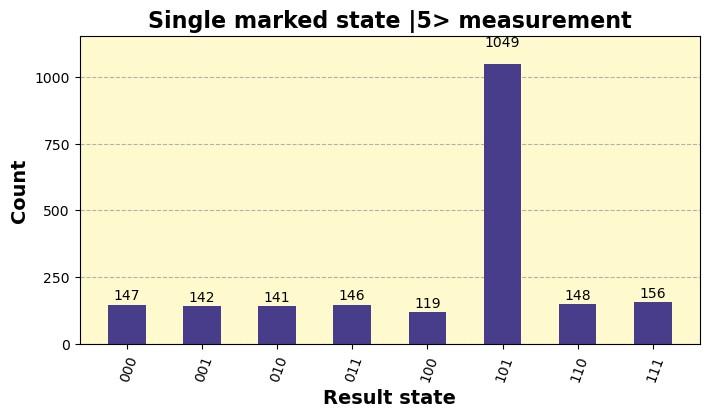

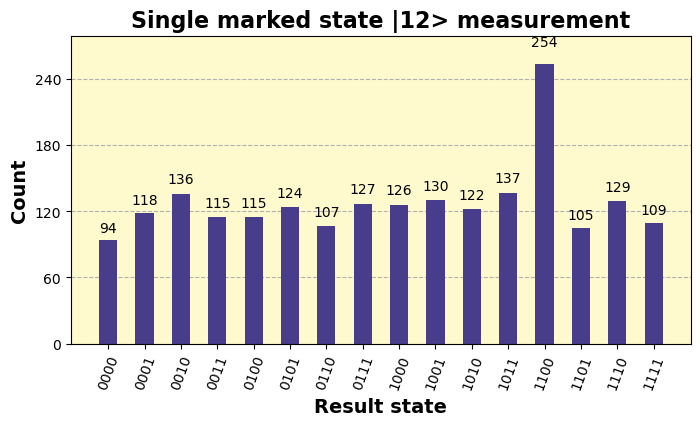

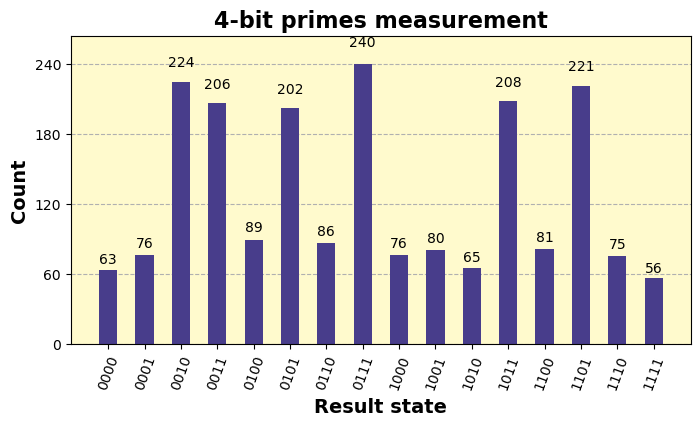

In [4]:
# --- Define test oracles ---
test_oracles = [
    (oracle_single_target, 3, 5, "Single marked state |5>"),
    (oracle_single_target, 4, 12, "Single marked state |12>"),
    (oracle_primes, 4, None, "4-bit primes")
]

shots = 2048

# --- Run tests ---
for oracle_func, n, target, desc in test_oracles:
    print(f"\n--- Testing Grover's algorithm: {desc}, n={n} ---")
    try:
        qc, counts = grover_run(oracle_func, target=target, n=n, shots=shots)
        # Sort counts for clearer reading
        sorted_counts = dict(sorted(counts.items(), key=lambda item: int(item[0], 2)))
        print("Measurement histogram (top states amplified):")
        for state, count in sorted_counts.items():
            decimal_value = int(state, 2)
            print(f"{state} ({decimal_value}): {count}")

        # Plot histogram
        fig = plt.figure(figsize=(8,4), clear=True)
        ax = fig.add_subplot(111)
        ax.set_facecolor('lemonchiffon')
        ax.set_title(f'{desc} measurement', fontweight='bold', fontsize=16)
        ax.set_xlabel('Result state', fontweight='bold', fontsize=14)
        ax.set_ylabel('Number of counts', fontweight='bold', fontsize=14)

        plot_histogram(counts, color='darkslateblue', ax=ax)

    except ValueError as e:
        print("Error detected:", e)